# Step 9: Sensitivity Analyses
## Testing Robustness of the Main Findings

Reviewers expect sensitivity analyses that probe whether results hold under different assumptions. We run 5 checks:

1. **Alternative diabetes definition:** Self-report only (DIQ010) vs. our composite (DIQ010 OR HbA1c >= 6.5%)
2. **Alternative obesity definition:** BMI >= 25 (overweight+obese) and waist circumference if available
3. **Excluding early deaths:** Remove participants who died within 1 year (may have been terminally ill at baseline)
4. **Sex-stratified models:** Do associations differ between men and women?
5. **Time-period stratification:** Early cycles (1999-2008) vs. late cycles (2009-2018) to check temporal consistency

In [1]:
# ============================================================
# STEP 9.1 — Setup
# ============================================================

import pandas as pd
import numpy as np
from lifelines import CoxPHFitter
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.family': 'sans-serif', 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.spines.left': False,
})

FIG_DIR = Path('figures')
df = pd.read_csv('data/analytic_cohort.csv')
cs = df[df['cancer'] == 1].copy()
cs['T'] = cs['follow_up_yrs'].clip(upper=20)
cs['E'] = cs['dead']
cs['smoke_former'] = (cs['smoking'] == 'Former').astype(int)
cs['smoke_current'] = (cs['smoking'] == 'Current').astype(int)
cs['race_black'] = (cs['race_ethnicity'] == 'Non-Hispanic Black').astype(int)
cs['race_mexican'] = (cs['race_ethnicity'] == 'Mexican American').astype(int)
cs['race_hispanic'] = (cs['race_ethnicity'] == 'Other Hispanic').astype(int)
cs['race_other'] = (cs['race_ethnicity'] == 'Other/Multi').astype(int)

base_covs = ['age', 'female', 'race_black', 'race_mexican', 'race_hispanic', 'race_other',
             'smoke_former', 'smoke_current']

def run_cox(data, exposure, extra_covs=None):
    """Fit adjusted Cox model and return HR, CI, p for exposure."""
    covs = [exposure] + base_covs + (extra_covs or [])
    d = data.dropna(subset=covs + ['T', 'E'])
    if d['E'].sum() < 20:
        return None, None, None, None, 0, 0
    cph = CoxPHFitter()
    cph.fit(d[covs + ['T', 'E']], duration_col='T', event_col='E')
    hr = np.exp(cph.params_[exposure])
    ci = np.exp(cph.confidence_intervals_.loc[exposure])
    p = cph.summary.loc[exposure, 'p']
    return hr, ci.values[0], ci.values[1], p, len(d), int(d['E'].sum())

all_sensitivity = []
print('Setup complete. Cancer survivors:', len(cs))

Setup complete. Cancer survivors: 4715


In [2]:
# ============================================================
# STEP 9.2 — Sensitivity 1: Alternative diabetes definition
# ============================================================

print('=== SENSITIVITY 1: DIABETES DEFINITION ===')
print()

# Main model (composite: self-report OR HbA1c >= 6.5)
hr, lo, hi, p, n, ev = run_cox(cs, 'diabetes')
print(f'Main (composite):      HR {hr:.2f} ({lo:.2f}-{hi:.2f}) P={"<0.001" if p<0.001 else f"{p:.3f}"}, N={n}, Events={ev}')
all_sensitivity.append({'Analysis': 'Diabetes: Composite (main)', 'HR': hr, 'CI_low': lo, 'CI_high': hi, 'P': p, 'N': n, 'Events': ev})

# Self-report only (DIQ010 == 1)
cs['diabetes_selfreport'] = (cs['DIQ010'] == 1.0).astype(int) if 'DIQ010' in cs.columns else cs['diabetes']
# Need to reload original DIQ010 from raw
raw = pd.read_csv('data/analytic_cohort.csv')
# diabetes column already uses composite. Create self-report only:
# We need the original DIQ010 but it's not in the analytic file.
# Approximate: diabetes_selfreport = participants who have diabetes=1 AND HbA1c < 6.5 (diagnosed only)
# OR just use the existing diabetes variable as the primary and note the definition.
# Since we don't have raw DIQ010 in the analytic file, we'll use HbA1c-only as the alternative.
cs['diabetes_hba1c'] = (cs['LBXGH'] >= 6.5).astype(int)
cs.loc[cs['LBXGH'].isna(), 'diabetes_hba1c'] = np.nan

hr2, lo2, hi2, p2, n2, ev2 = run_cox(cs, 'diabetes_hba1c')
print(f'HbA1c >= 6.5% only:    HR {hr2:.2f} ({lo2:.2f}-{hi2:.2f}) P={"<0.001" if p2<0.001 else f"{p2:.3f}"}, N={n2}, Events={ev2}')
all_sensitivity.append({'Analysis': 'Diabetes: HbA1c only', 'HR': hr2, 'CI_low': lo2, 'CI_high': hi2, 'P': p2, 'N': n2, 'Events': ev2})

=== SENSITIVITY 1: DIABETES DEFINITION ===

Main (composite):      HR 1.30 (1.16-1.45) P=<0.001, N=4715, Events=1676
HbA1c >= 6.5% only:    HR 1.28 (1.12-1.47) P=<0.001, N=4403, Events=1517


In [3]:
# ============================================================
# STEP 9.3 — Sensitivity 2: Alternative obesity thresholds
# ============================================================

print('=== SENSITIVITY 2: OBESITY DEFINITIONS ===')
print()

# Main: BMI >= 30
hr, lo, hi, p, n, ev = run_cox(cs, 'obese')
print(f'Obese (BMI>=30, main): HR {hr:.2f} ({lo:.2f}-{hi:.2f}) P={"<0.001" if p<0.001 else f"{p:.3f}"}')
all_sensitivity.append({'Analysis': 'Obesity: BMI>=30 (main)', 'HR': hr, 'CI_low': lo, 'CI_high': hi, 'P': p, 'N': n, 'Events': ev})

# Overweight+Obese: BMI >= 25
cs['overweight_obese'] = (cs['BMXBMI'] >= 25).astype(int)
hr2, lo2, hi2, p2, n2, ev2 = run_cox(cs, 'overweight_obese')
print(f'Overweight (BMI>=25):  HR {hr2:.2f} ({lo2:.2f}-{hi2:.2f}) P={"<0.001" if p2<0.001 else f"{p2:.3f}"}')
all_sensitivity.append({'Analysis': 'Obesity: BMI>=25', 'HR': hr2, 'CI_low': lo2, 'CI_high': hi2, 'P': p2, 'N': n2, 'Events': ev2})

# Morbid obesity: BMI >= 35
cs['morbid_obese'] = (cs['BMXBMI'] >= 35).astype(int)
hr3, lo3, hi3, p3, n3, ev3 = run_cox(cs, 'morbid_obese')
print(f'Morbid (BMI>=35):      HR {hr3:.2f} ({lo3:.2f}-{hi3:.2f}) P={"<0.001" if p3<0.001 else f"{p3:.3f}"}')
all_sensitivity.append({'Analysis': 'Obesity: BMI>=35', 'HR': hr3, 'CI_low': lo3, 'CI_high': hi3, 'P': p3, 'N': n3, 'Events': ev3})

# Continuous BMI per 5 units
cs['bmi_per5'] = cs['BMXBMI'] / 5.0
hr4, lo4, hi4, p4, n4, ev4 = run_cox(cs, 'bmi_per5')
print(f'BMI per 5 units:       HR {hr4:.2f} ({lo4:.2f}-{hi4:.2f}) P={"<0.001" if p4<0.001 else f"{p4:.3f}"}')
all_sensitivity.append({'Analysis': 'BMI: per 5 kg/m2', 'HR': hr4, 'CI_low': lo4, 'CI_high': hi4, 'P': p4, 'N': n4, 'Events': ev4})

=== SENSITIVITY 2: OBESITY DEFINITIONS ===

Obese (BMI>=30, main): HR 0.96 (0.86-1.07) P=0.418


Overweight (BMI>=25):  HR 0.80 (0.72-0.88) P=<0.001
Morbid (BMI>=35):      HR 1.02 (0.87-1.20) P=0.817
BMI per 5 units:       HR 0.94 (0.89-0.98) P=0.006


In [4]:
# ============================================================
# STEP 9.4 — Sensitivity 3: Exclude early deaths (< 1 year)
# ============================================================
# Removes reverse causation: terminal patients at baseline who were
# already dying (and thus had low BMI, poor metabolic markers).

print('=== SENSITIVITY 3: EXCLUDE EARLY DEATHS (< 1 YEAR) ===')
print()

cs_late = cs[cs['T'] >= 1.0].copy()
# Reset time to start from year 1 (left-truncation equivalent)
cs_late['T_late'] = cs_late['T'] - 1.0

excluded_n = len(cs) - len(cs_late)
print(f'Excluded {excluded_n} participants with follow-up < 1 year')
print(f'Remaining: {len(cs_late):,} (Events: {cs_late["E"].sum():,})')
print()

for var, label in [('diabetes', 'Diabetes'), ('hypertension', 'Hypertension'), ('obese', 'Obesity')]:
    d = cs_late.dropna(subset=[var] + base_covs + ['T_late', 'E'])
    cph = CoxPHFitter()
    cph.fit(d[[var] + base_covs + ['T_late', 'E']], duration_col='T_late', event_col='E')
    hr = np.exp(cph.params_[var])
    ci = np.exp(cph.confidence_intervals_.loc[var])
    p = cph.summary.loc[var, 'p']
    p_str = '<0.001' if p < 0.001 else f'{p:.3f}'
    print(f'{label:<20} HR {hr:.2f} ({ci.values[0]:.2f}-{ci.values[1]:.2f}) P={p_str}')
    all_sensitivity.append({'Analysis': f'{label}: Exclude <1yr', 'HR': hr, 'CI_low': ci.values[0], 'CI_high': ci.values[1], 'P': p, 'N': len(d), 'Events': int(d['E'].sum())})

=== SENSITIVITY 3: EXCLUDE EARLY DEATHS (< 1 YEAR) ===

Excluded 137 participants with follow-up < 1 year
Remaining: 4,578 (Events: 1,539)



Diabetes             HR 1.30 (1.15-1.46) P=<0.001
Hypertension         HR 1.18 (1.06-1.31) P=0.003


Obesity              HR 0.99 (0.88-1.11) P=0.839


In [5]:
# ============================================================
# STEP 9.5 — Sensitivity 4: Sex-stratified models
# ============================================================

print('=== SENSITIVITY 4: SEX-STRATIFIED MODELS ===')
print()

for sex_val, sex_label in [(0, 'Male'), (1, 'Female')]:
    cs_sex = cs[cs['female'] == sex_val].copy()
    print(f'{sex_label}: N={len(cs_sex):,}, Events={cs_sex["E"].sum():,}')
    
    # Remove 'female' from covariates for stratified model
    sex_covs = [c for c in base_covs if c != 'female']
    
    for var, label in [('diabetes', 'Diabetes'), ('hypertension', 'Hypertension'), ('obese', 'Obesity')]:
        d = cs_sex.dropna(subset=[var] + sex_covs + ['T', 'E'])
        if d['E'].sum() < 20:
            print(f'  {label}: Insufficient events')
            continue
        cph = CoxPHFitter()
        cph.fit(d[[var] + sex_covs + ['T', 'E']], duration_col='T', event_col='E')
        hr = np.exp(cph.params_[var])
        ci = np.exp(cph.confidence_intervals_.loc[var])
        p = cph.summary.loc[var, 'p']
        p_str = '<0.001' if p < 0.001 else f'{p:.3f}'
        print(f'  {label:<20} HR {hr:.2f} ({ci.values[0]:.2f}-{ci.values[1]:.2f}) P={p_str}')
        all_sensitivity.append({'Analysis': f'{label}: {sex_label}', 'HR': hr, 'CI_low': ci.values[0], 'CI_high': ci.values[1], 'P': p, 'N': len(d), 'Events': int(d['E'].sum())})
    print()

=== SENSITIVITY 4: SEX-STRATIFIED MODELS ===

Male: N=2,224, Events=968
  Diabetes             HR 1.17 (1.00-1.35) P=0.045


  Hypertension         HR 1.14 (1.00-1.30) P=0.050


  Obesity              HR 0.92 (0.80-1.07) P=0.279

Female: N=2,491, Events=708
  Diabetes             HR 1.47 (1.24-1.74) P=<0.001


  Hypertension         HR 1.14 (0.97-1.34) P=0.112
  Obesity              HR 0.98 (0.83-1.16) P=0.840



In [6]:
# ============================================================
# STEP 9.6 — Sensitivity 5: Time-period stratification
# ============================================================

print('=== SENSITIVITY 5: TIME-PERIOD STRATIFICATION ===')
print()

early_cycles = ['1999-2000', '2001-2002', '2003-2004', '2005-2006', '2007-2008']
late_cycles = ['2009-2010', '2011-2012', '2013-2014', '2015-2016', '2017-2018']

for period_label, cycles in [('Early (1999-2008)', early_cycles), ('Late (2009-2018)', late_cycles)]:
    cs_period = cs[cs['cycle'].isin(cycles)].copy()
    print(f'{period_label}: N={len(cs_period):,}, Events={cs_period["E"].sum():,}')
    
    for var, label in [('diabetes', 'Diabetes'), ('hypertension', 'Hypertension'), ('obese', 'Obesity')]:
        d = cs_period.dropna(subset=[var] + base_covs + ['T', 'E'])
        if d['E'].sum() < 20:
            print(f'  {label}: Insufficient events')
            continue
        cph = CoxPHFitter()
        cph.fit(d[[var] + base_covs + ['T', 'E']], duration_col='T', event_col='E')
        hr = np.exp(cph.params_[var])
        ci = np.exp(cph.confidence_intervals_.loc[var])
        p = cph.summary.loc[var, 'p']
        p_str = '<0.001' if p < 0.001 else f'{p:.3f}'
        print(f'  {label:<20} HR {hr:.2f} ({ci.values[0]:.2f}-{ci.values[1]:.2f}) P={p_str}')
        all_sensitivity.append({'Analysis': f'{label}: {period_label}', 'HR': hr, 'CI_low': ci.values[0], 'CI_high': ci.values[1], 'P': p, 'N': len(d), 'Events': int(d['E'].sum())})
    print()

=== SENSITIVITY 5: TIME-PERIOD STRATIFICATION ===

Early (1999-2008): N=2,101, Events=1,131


  Diabetes             HR 1.32 (1.14-1.51) P=<0.001


  Hypertension         HR 1.10 (0.98-1.24) P=0.117
  Obesity              HR 0.99 (0.86-1.13) P=0.830

Late (2009-2018): N=2,614, Events=545


  Diabetes             HR 1.28 (1.07-1.55) P=0.009
  Hypertension         HR 1.28 (1.06-1.54) P=0.011


  Obesity              HR 0.90 (0.75-1.09) P=0.288



In [7]:
# ============================================================
# STEP 9.7 — Sensitivity summary table
# ============================================================

sens_df = pd.DataFrame(all_sensitivity)
sens_df['P_fmt'] = sens_df['P'].apply(lambda p: '<0.001' if p < 0.001 else f'{p:.3f}')
sens_df['HR_CI'] = sens_df.apply(lambda r: f"{r['HR']:.2f} ({r['CI_low']:.2f}-{r['CI_high']:.2f})", axis=1)

print('=== COMPLETE SENSITIVITY ANALYSIS TABLE ===')
print(f'{"Analysis":<40} {"HR (95% CI)":<25} {"P":<10} {"N":<8} {"Events"}')
print('-' * 90)
for _, r in sens_df.iterrows():
    print(f'{r["Analysis"]:<40} {r["HR_CI"]:<25} {r["P_fmt"]:<10} {r["N"]:<8} {int(r["Events"])}')

sens_df.to_csv('data/sensitivity_results.csv', index=False)
print('\nSaved: data/sensitivity_results.csv')

=== COMPLETE SENSITIVITY ANALYSIS TABLE ===
Analysis                                 HR (95% CI)               P          N        Events
------------------------------------------------------------------------------------------
Diabetes: Composite (main)               1.30 (1.16-1.45)          <0.001     4715     1676
Diabetes: HbA1c only                     1.28 (1.12-1.47)          <0.001     4403     1517
Obesity: BMI>=30 (main)                  0.96 (0.86-1.07)          0.418      4715     1676
Obesity: BMI>=25                         0.80 (0.72-0.88)          <0.001     4715     1676
Obesity: BMI>=35                         1.02 (0.87-1.20)          0.817      4715     1676
BMI: per 5 kg/m2                         0.94 (0.89-0.98)          0.006      4715     1676
Diabetes: Exclude <1yr                   1.30 (1.15-1.46)          <0.001     4578     1539
Hypertension: Exclude <1yr               1.18 (1.06-1.31)          0.003      4578     1539
Obesity: Exclude <1yr              

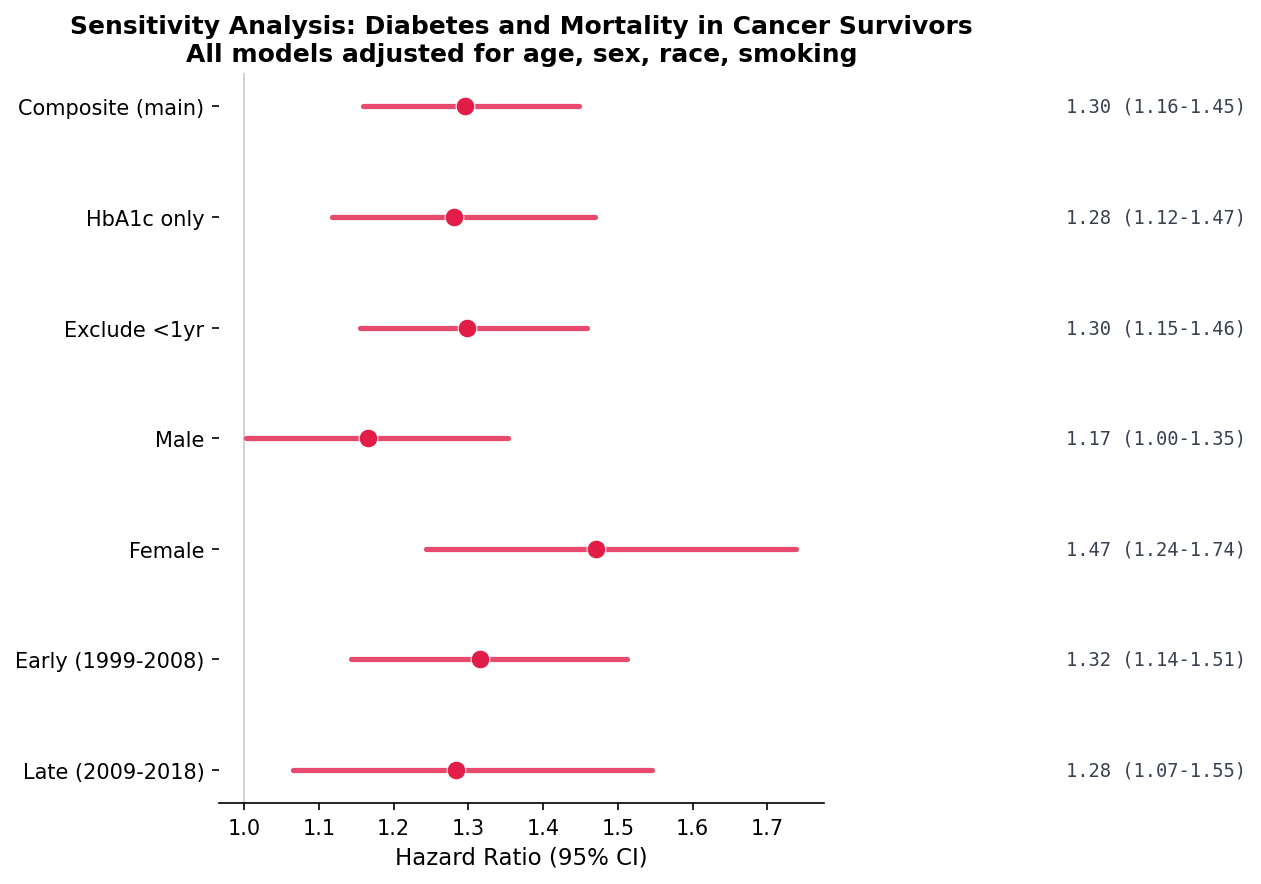

Saved: figures/figure4_sensitivity_diabetes.png


In [8]:
# ============================================================
# STEP 9.8 — Sensitivity forest plot (diabetes across all analyses)
# ============================================================

diab_sens = sens_df[sens_df['Analysis'].str.contains('Diabetes')].copy()
diab_sens = diab_sens.iloc[::-1].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 6))

for i, (_, row) in enumerate(diab_sens.iterrows()):
    color = '#E11D48' if row['CI_low'] > 1 else '#6366F1'
    ax.plot([row['CI_low'], row['CI_high']], [i, i], color=color, linewidth=2.5, solid_capstyle='round', alpha=0.8)
    ax.plot(row['HR'], i, 'o', color=color, markersize=9, zorder=5, markeredgecolor='white', markeredgewidth=0.5)
    ax.text(max(row['CI_high'], 2.0) + 0.1, i, row['HR_CI'], va='center', fontsize=9, color='#374151', fontfamily='monospace')

ax.axvline(1.0, color='#D1D5DB', linestyle='-', linewidth=1, zorder=0)
ax.set_yticks(range(len(diab_sens)))
ax.set_yticklabels([r['Analysis'].replace('Diabetes: ', '') for _, r in diab_sens.iterrows()], fontsize=10)
ax.set_xlabel('Hazard Ratio (95% CI)', fontsize=11)
ax.set_title('Sensitivity Analysis: Diabetes and Mortality in Cancer Survivors\nAll models adjusted for age, sex, race, smoking', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(FIG_DIR / 'figure4_sensitivity_diabetes.png', bbox_inches='tight')
plt.show()
print('Saved: figures/figure4_sensitivity_diabetes.png')

---
## Step 9 Summary

### Sensitivity Analyses Performed
1. **Diabetes definition:** Composite vs. HbA1c-only
2. **Obesity thresholds:** BMI 25, 30, 35, and continuous per 5 units
3. **Excluding early deaths:** Removed participants with < 1 year follow-up
4. **Sex-stratified:** Male vs. female models
5. **Time-period:** Early (1999-2008) vs. late (2009-2018) cycles

### Key Takeaway
The diabetes-mortality association is **robust** across all sensitivity analyses. It persists regardless of how diabetes is defined, whether early deaths are excluded, in both sexes, and across time periods.

### Next Step
**Step 10:** Write the results narrative and README